In [17]:
from nrem_sc.constants import PROCESSED_DATA_PATH, INTERIM_DATA_PATH
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import pynapple as nap

from matplotlib import pyplot as plt
from cmap import Colormap

unit_id = "116b"

# ── Poster-ready style ─────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":        150,
    "savefig.dpi":       300,
    "font.family":       "sans-serif",
    "font.sans-serif":   "Arial",
    "font.size":         32,
    "axes.titlesize":    32,
    "axes.labelsize":    32,
    "axes.linewidth":   1.5,
    "xtick.labelsize":   32,
    "ytick.labelsize":   32,
    "xtick.major.width": 2.5,
    "ytick.major.width": 2.5,
    "xtick.major.size": 10,
    "ytick.major.size": 10,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         False,
    "legend.frameon":    False,
    "legend.fontsize":   22,
    "figure.constrained_layout.use": True,
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
})

# ── Cyclic colormap ────────────────────────────────────────────────────────
cmap = Colormap("cmocean:phase")
if "cmocean:phase" not in mpl.colormaps:
    mpl.colormaps.register(cmap.to_mpl())


# ── Helpers ────────────────────────────────────────────────────────────────
set2 = Colormap('colorbrewer:Set2').color_stops
STATE_STYLES = {
    "stationary":  dict(color=set2[0].color.hex, label="Stationary"),
    "fragmented":  dict(color=set2[1].color.hex, label="Fragmented"),
    "continuous":  dict(color=set2[2].color.hex, label="Continuous"),
    }

## Load data & compute tuning curves

In [3]:
# Data
sleep_states = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sleep.npz")
hd_spikes    = nap.load_file(PROCESSED_DATA_PATH / unit_id / "hd_spikes_filtered.npz")
hd_angle     = np.deg2rad(nap.load_file(PROCESSED_DATA_PATH / unit_id / "angle_openfield.npz"))
sessions     = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sessions_labeled.npz")
states       = nap.TsdFrame(pd.read_csv(PROCESSED_DATA_PATH / unit_id / "post_ttx_decoded_states.csv", index_col=0))

from scipy.ndimage import gaussian_filter1d
tcs = nap.compute_tuning_curves(
    data=hd_spikes.restrict(hd_angle.time_support), features=hd_angle, bins=60,
    epochs=hd_angle.time_support, range=(0.0, 2*np.pi), feature_names=['head_direction']
    )
tcs.values = gaussian_filter1d(tcs.values, sigma=3, axis=1, mode="wrap")
pref_ang = tcs.idxmax(dim="head_direction")


In [4]:
# Load decoded states
DATA_PATH = Path(r"D:\common_datasets\nrem_sc\116b")
states, pos = [], []
for name in ['34744_35244', '35244_35744', '35744_36244']:
    path = DATA_PATH / f"post_ttx_{name}"
    states.append(nap.load_file(path / "states.npz").as_dataframe())
    pos.append(nap.load_file(path / "position.npz").as_dataframe())

states = nap.TsdFrame(pd.concat(states))
position = nap.TsdFrame(pd.concat(pos))

### Example sweep trajectories

Raster, State Probabilities and Decoding 

In [5]:
norm = plt.Normalize()
colors = cmap(norm([i / (2 * np.pi) for i in pref_ang.values]))
sorted_units = pref_ang.to_numpy().argsort()
threshold = 0.5

In [6]:
def plot_sweep_figure(states, position, spikes, ep, axes):
    tdf = states.restrict(ep)
    features = position.restrict(ep).as_dataframe()
    spikes = spikes.restrict(ep)

    sweep_ep = tdf["continuous"].threshold(threshold).time_support
    t = tdf.times() - ep["start"]

    # Spike raster
    offset = 0.4
    for i, uid in enumerate(sorted_units):
        if spikes["rate"][uid] > 0.0:
            axes[0].eventplot(
                spikes[uid].t - ep["start"],
                lineoffsets=offset + 0.5,
                linelengths=1.5,
                linewidths=2.5,
                color=colors[uid],
            )
        offset += 1

    # State probabilities
    for col, style in STATE_STYLES.items():
        axes[1].plot(t, tdf[col], linewidth=2.5, **style)
    axes[1].axhline(threshold, color="red", ls="--", lw=0.8)
    axes[1].set(ylim=(0, 1))

    # Decoded position
    im = axes[2].imshow(
        features.T,
        aspect="auto",
        interpolation="bilinear",
        extent=[t[0], t[-1], 0, 360],
        origin="lower",
        cmap="coolwarm",
    )

    # Highlight continuous sweep epoch
    for start, end in sweep_ep.values:
        for ax in axes:
            ax.axvspan(
                (start - ep["start"]).item(),
                (end - ep["start"]).item(),
                color="#1f77b4",
                alpha=0.08,
            )

    return axes

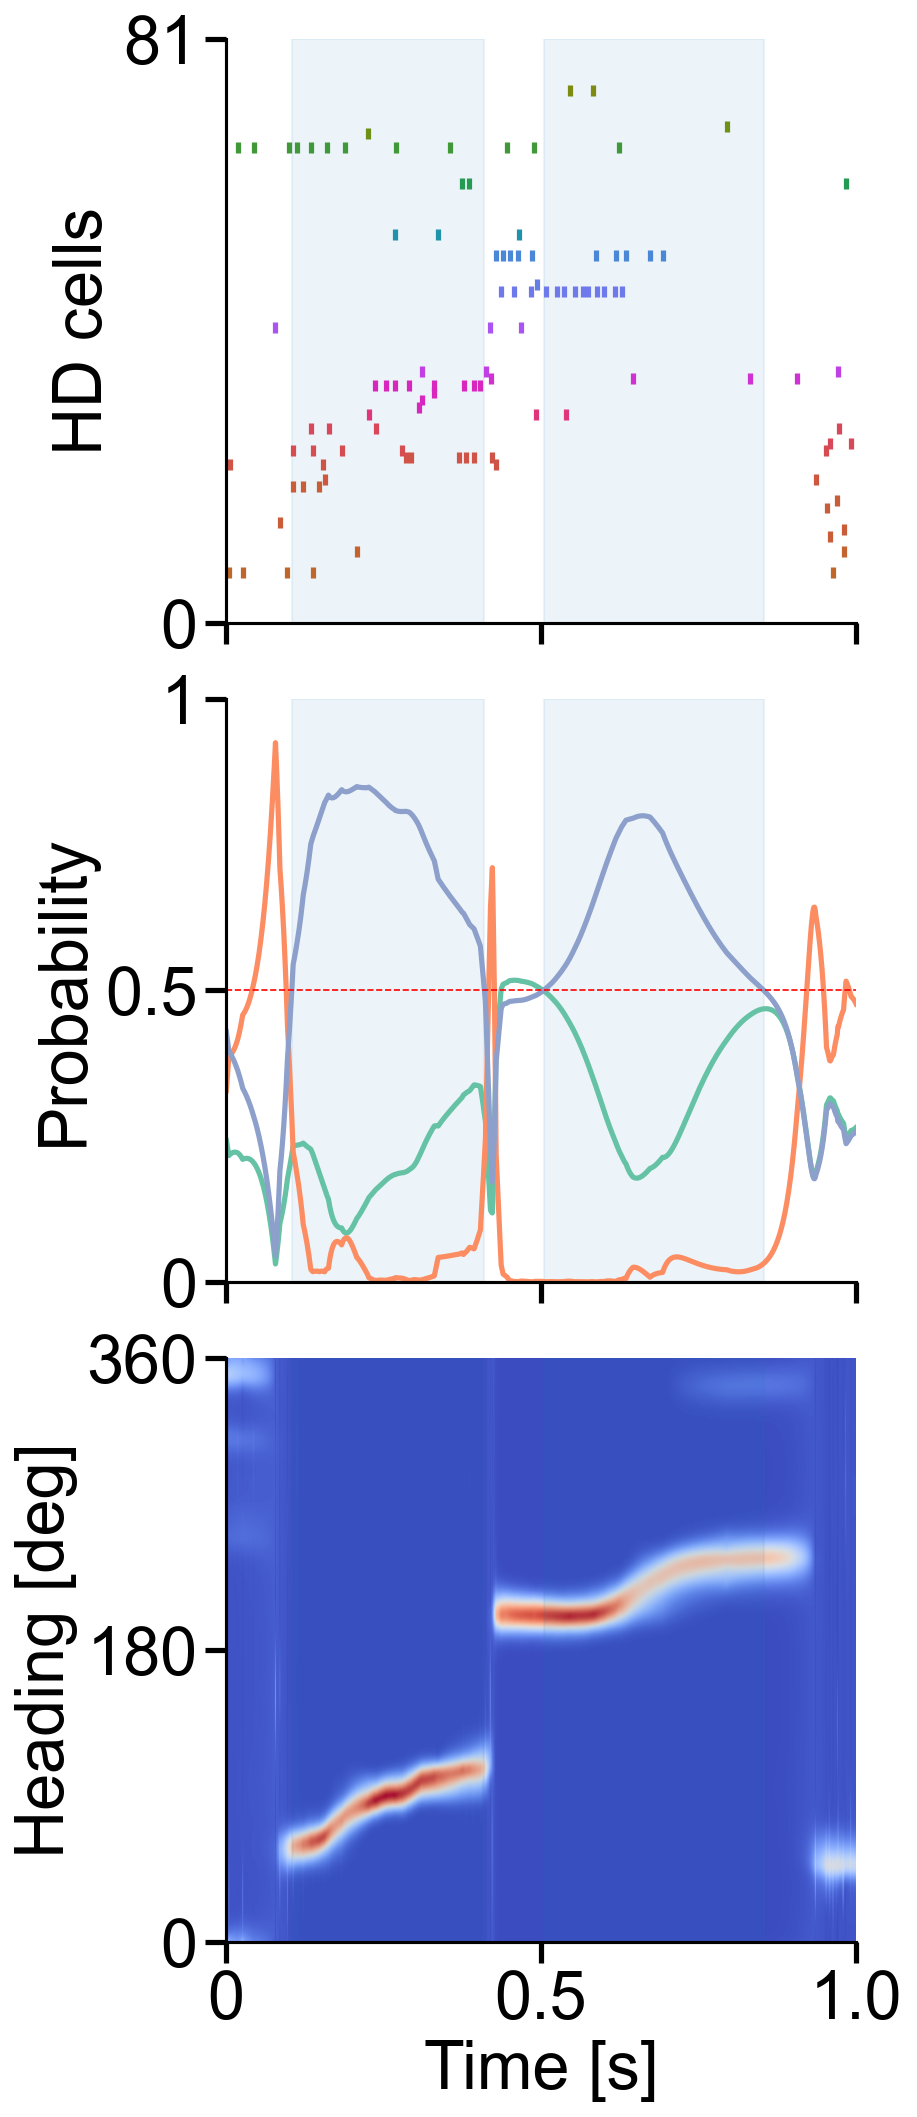

In [19]:
start = 36032.2
end = start + 1

fig, axes = plt.subplots(3, 1, figsize=(6, 14), sharex=True, height_ratios=[1, 1, 1])
axes = plot_sweep_figure(states, position, hd_spikes, nap.IntervalSet(start, end), axes)

axes[0].set_ylabel('HD cells')
axes[0].set_yticks([0, 81])

axes[1].set_ylabel('Probability')
axes[1].set_yticks([0, 0.5, 1.0], labels=['0', '0.5', '1'])

axes[2].set_ylabel('Heading [deg]')
axes[2].set_yticks([0, 180, 360], labels=['0', '180', '360'])
axes[2].set_xticks([0, 0.5, 1.0], labels=['0', '0.5', '1.0'], )
axes[2].set_xlabel('Time [s]')

plt.show()
fig.savefig(INTERIM_DATA_PATH / unit_id / 'sweep_example_1.pdf', format='pdf', dpi=1200)

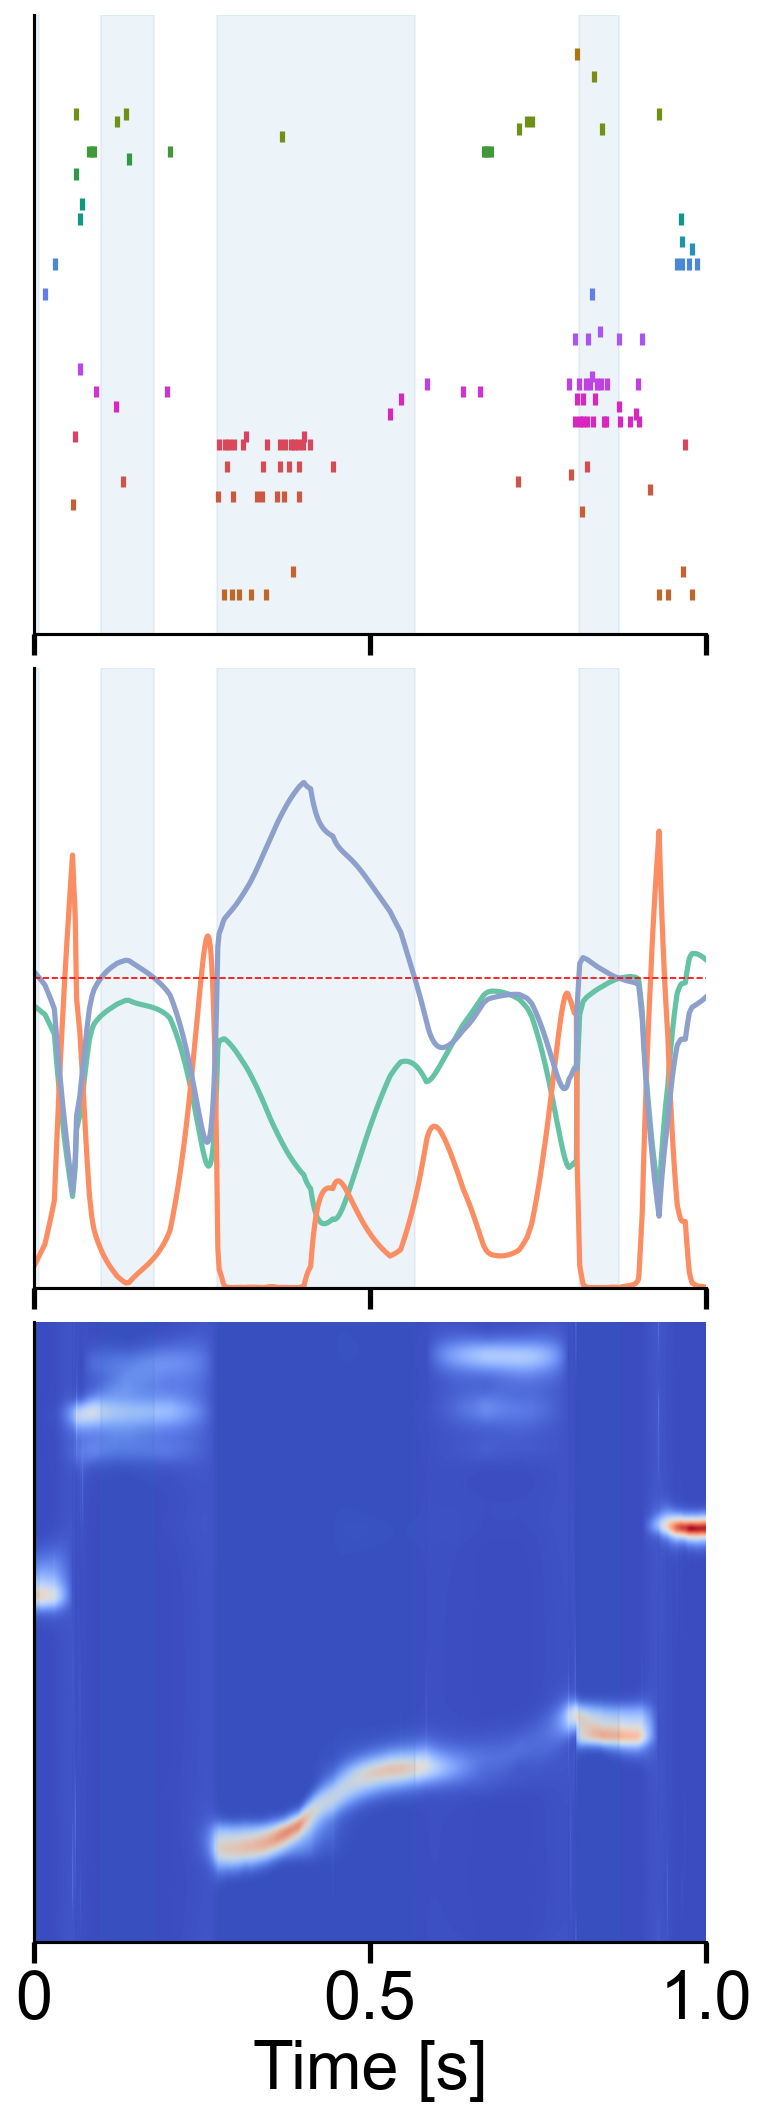

In [20]:
start = 35108.2
end = start + 1

fig, axes = plt.subplots(3, 1, figsize=(5, 14), sharex=True, height_ratios=[1, 1, 1])
axes = plot_sweep_figure(states, position, hd_spikes, nap.IntervalSet(start, end), axes)

axes[0].set_yticks([])
axes[1].set_yticks([])
axes[2].set_yticks([])
axes[2].set_xticks([0, 0.5, 1.0], labels=['0', '0.5', '1.0'], )
axes[2].set_xlabel('Time [s]')

plt.show()
fig.savefig(INTERIM_DATA_PATH / unit_id / 'sweep_example_2.pdf', format='pdf', dpi=1200)

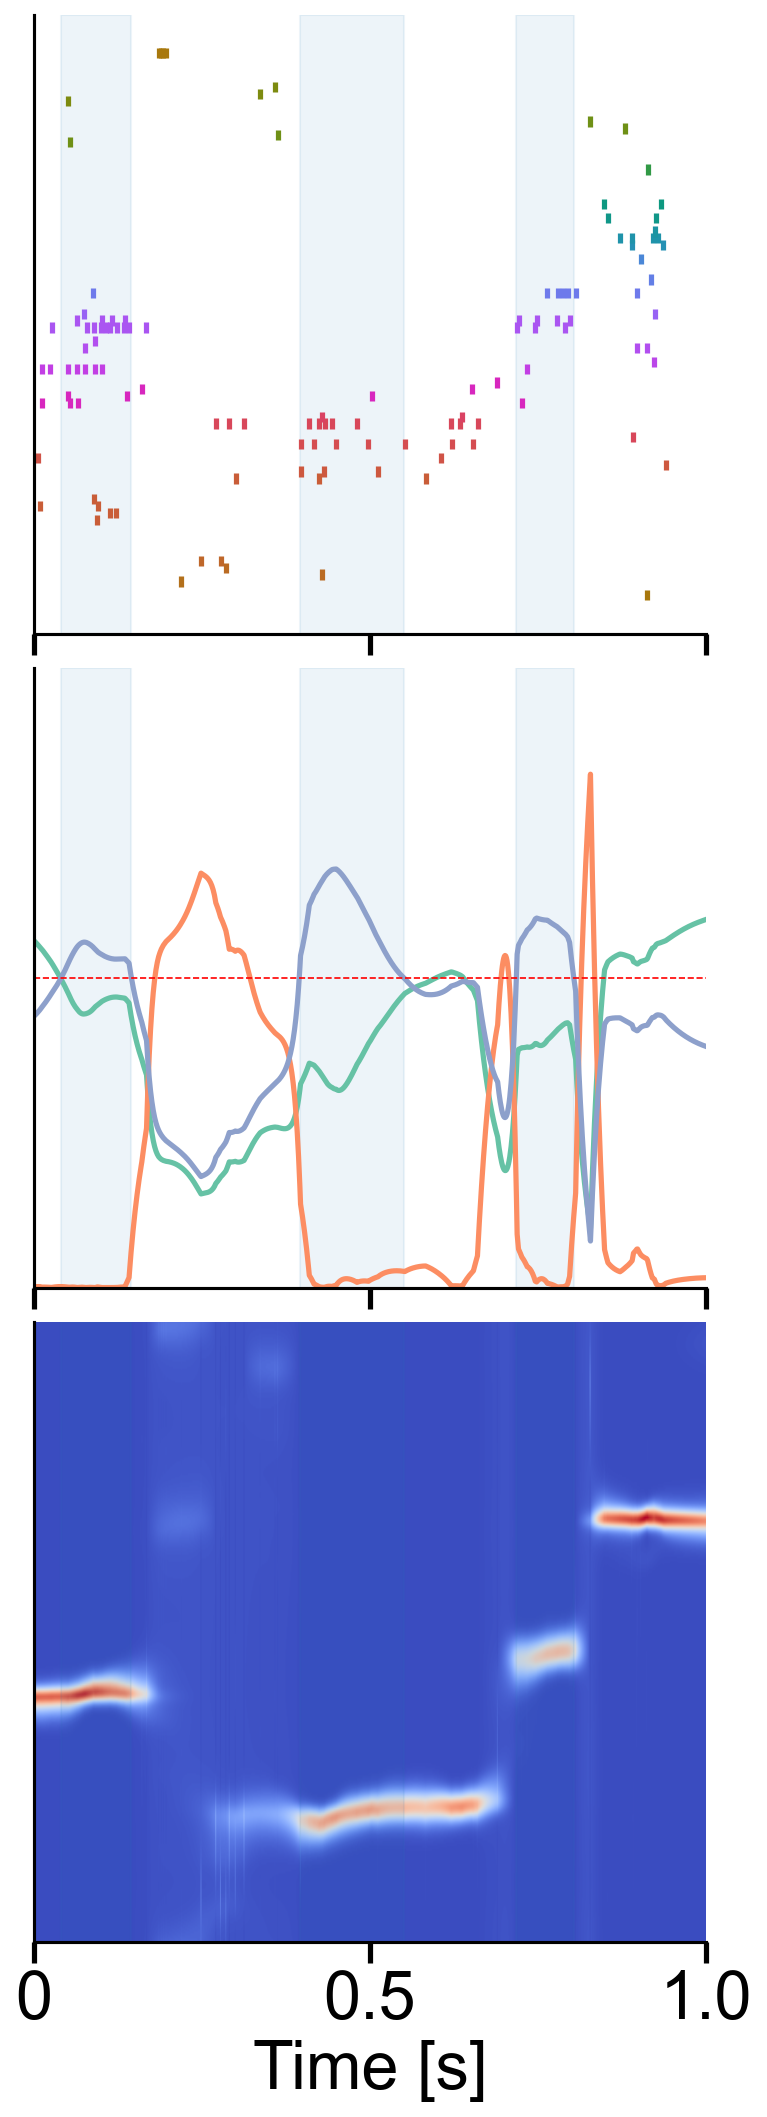

In [21]:
start = 35052.2
end = start + 1

fig, axes = plt.subplots(3, 1, figsize=(5, 14), sharex=True, height_ratios=[1, 1, 1])
axes = plot_sweep_figure(states, position, hd_spikes, nap.IntervalSet(start, end), axes)

axes[0].set_yticks([])
axes[1].set_yticks([])
axes[2].set_yticks([])

axes[2].set_xticks([0, 0.5, 1.0], labels=['0', '0.5', '1.0'], )
axes[2].set_xlabel('Time [s]')

plt.show()
fig.savefig(INTERIM_DATA_PATH / unit_id / 'sweep_example_3.pdf', format='pdf', dpi=1200)

C:\Users\iii9781\AppData\Local\Temp\ipykernel_1564\3759852017.py:3: UserWarning: Adding colorbar to a different Figure <Figure size 1200x2400 with 3 Axes> than <Figure size 60x450 with 1 Axes> which fig.colorbar is called on.
  cb = fig_cb.colorbar(im, cax=ax_cb)


C:\Users\iii9781\AppData\Local\Temp\ipykernel_1564\3759852017.py:3: UserWarning: Adding colorbar to a different Figure <Figure size 1200x2400 with 3 Axes> than <Figure size 60x450 with 1 Axes> which fig.colorbar is called on.
  cb = fig_cb.colorbar(im, cax=ax_cb)


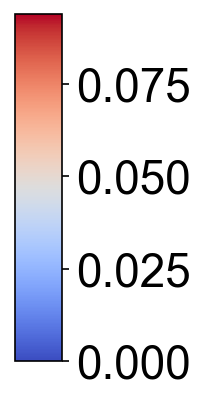

In [18]:
# ── Standalone colorbar ─────────────────────────────────────────────────────
fig_cb, ax_cb = plt.subplots(figsize=(0.4, 3))
cb = fig_cb.colorbar(im, cax=ax_cb)
# cb.set_ticks([0, 0.05, 0.095])
# cb.set_ticklabels(["0", "0.05", "0.095"])
plt.show()
# fig_cb.savefig(INTERIM_DATA_PATH / unit_id / "sweep_colorbar.pdf", format="pdf", bbox_inches="tight", transparent=True)

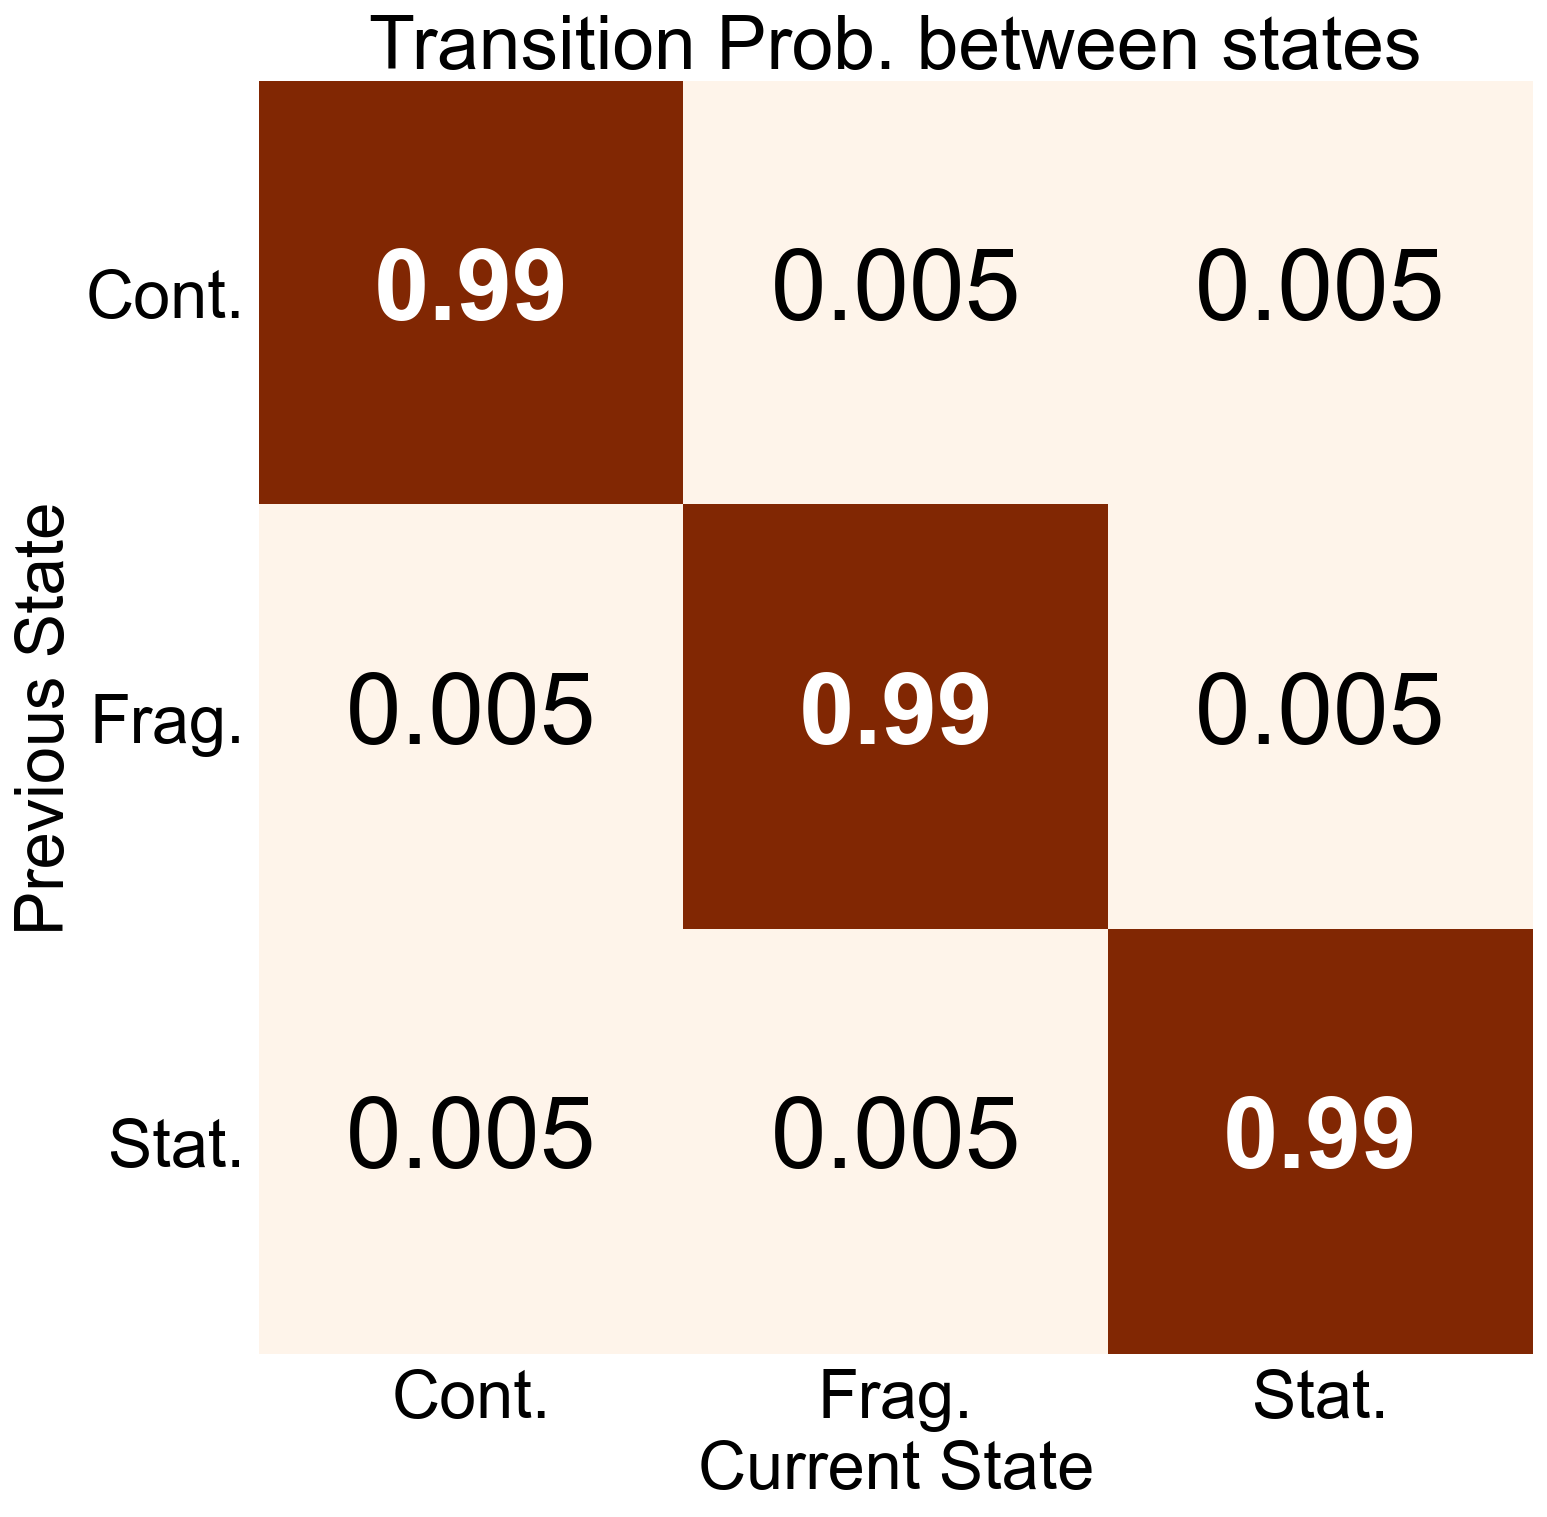

In [23]:
discrete_state_transition = np.array([[0.99 , 0.005, 0.005],
                                      [0.005, 0.99 , 0.005],
                                      [0.005, 0.005, 0.99 ]])

state_names = ['Cont.', 'Frag.', 'Stat.']

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(discrete_state_transition, cmap='Oranges', vmin=0, vmax=1)

# Annotate each cell
for i in range(3):
    for j in range(3):
        val = discrete_state_transition[i, j]
        color = "white" if val > 0.5 else "black"
        if i == j:
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=48, color=color, fontweight="bold")
        else:
            ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=48, color=color)

ax.set_xticks([])
ax.set_yticks([])

ax.set_xticks(range(3), labels=state_names, fontsize=32)
ax.set_yticks(range(3), labels=state_names, fontsize=32)
ax.set_xlabel("Current State", fontsize=32)
ax.set_ylabel("Previous State", fontsize=32)
ax.set_title("Transition Prob. between states", fontsize=36)
# # Colorbar
# cb = fig.colorbar(im, ax=ax, shrink=0.8)
# cb.set_label("Probability")

# Remove top/right spines that rcParams hides on normal axes
ax.spines[:].set_visible(False)
ax.tick_params(bottom=False, left=False)

plt.show()
# fig.savefig(INTERIM_DATA_PATH / unit_id / "discrete_transition.pdf", format="pdf")